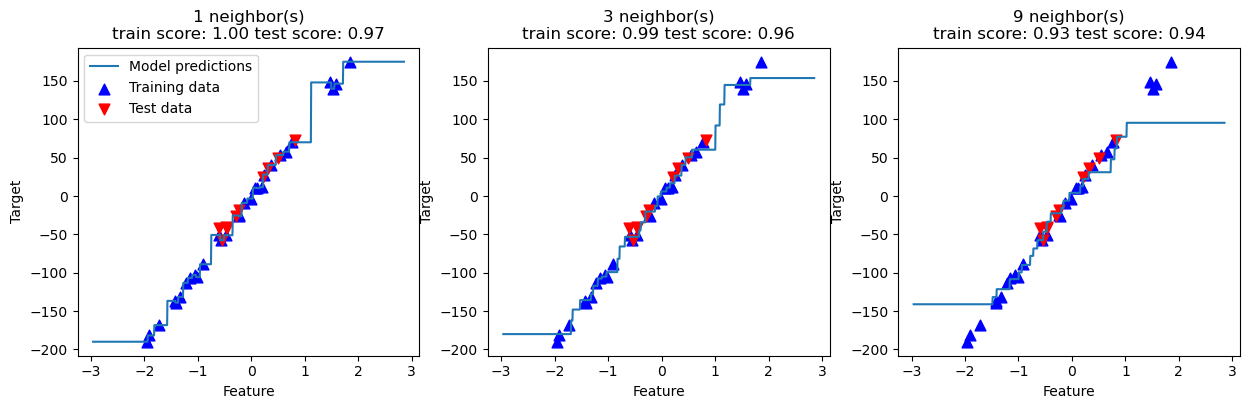

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Create a 1D regression dataset
X, y = make_regression(n_samples=40, n_features=1, noise=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Create 1000 evenly spaced points for plotting predictions
line = np.linspace(X.min()-1, X.max()+1, 1000).reshape(-1, 1)

# Loop over different neighbors
for n_neighbors, ax in zip([1, 3, 9], axes):
    # Train KNN regressor
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    
    # Plot predictions
    ax.plot(line, reg.predict(line), label="Model predictions")
    
    # Plot training data
    ax.scatter(X_train, y_train, marker='^', c='blue', s=60, label="Training data")
    
    # Plot test data
    ax.scatter(X_test, y_test, marker='v', c='red', s=60, label="Test data")
    
    # Set title and labels
    ax.set_title(
        "{} neighbor(s)\ntrain score: {:.2f} test score: {:.2f}".format(
            n_neighbors, reg.score(X_train, y_train), reg.score(X_test, y_test)
        )
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")

# Add legend to first subplot
axes[0].legend(loc="best")
plt.show()